# TP - Clasificación Multiclase de Texto con Regresión Softmax
### Redes Neuronales / Deep Learning

Dataset: **20 Newsgroups** (~18.000 posts de foros de Usenet, clasificados en 20 categorías).

## Objetivos
- Implementar un pipeline de preprocesamiento de texto **configurable** (stopwords, stemming, lematización, n-gramas).
- Implementar una **Regresión Softmax** (regresión logística multinomial) en PyTorch: una única capa lineal + `CrossEntropyLoss`, sin capas ocultas.
- Trackear el entrenamiento con **TensorBoard** y **MLflow**.
- Usar **Optuna** para buscar la mejor combinación de hiperparámetros de preprocesamiento *y* de entrenamiento en conjunto.

## Qué hay que completar
Los bloques marcados `# TODO` son los que tienen que completar ustedes. El resto ya está resuelto.

Esta notebook es individual/standalone: no tiene una sección de defensa grupal asociada.


## 0. Setup

In [ ]:
!pip install -q mlflow optuna


In [2]:
import re
import random
import time
import io
import contextlib
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

from torch.utils.tensorboard import SummaryWriter
import mlflow
import mlflow.pytorch
import optuna

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)


Usando dispositivo: cpu


/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Frameworks utilizados

| Framework | Para qué lo usamos |
|---|---|
| **scikit-learn** | Descarga del dataset (`fetch_20newsgroups`), vectorización `TfidfVectorizer`, split train/val estratificado y métricas (accuracy, matriz de confusión, `classification_report`). |
| **NLTK** | Tokenización (`word_tokenize`), lista de stopwords en inglés, `PorterStemmer` y `WordNetLemmatizer`. |
| **PyTorch** | Definición del modelo (`nn.Module` con un `nn.Linear`), loss (`CrossEntropyLoss`), optimizador (`Adam`/`SGD`), `DataLoader` para iterar en mini-batches y autograd para calcular gradientes. |
| **TensorBoard** | Visualización interactiva de las curvas de loss/accuracy por época (`SummaryWriter` → carpeta `runs/`). |
| **MLflow** | *Experiment tracking*: por cada run guarda hiperparámetros, métricas por época, tiempo de entrenamiento y el modelo final, para poder comparar runs entre sí. |
| **Optuna** | Búsqueda automática de hiperparámetros con TPE (*Tree-structured Parzen Estimator*): propone combinaciones nuevas en base a los resultados de los trials anteriores. |
| **pandas / matplotlib** | Tablas y gráficos para el análisis de resultados. |

La celda fija las semillas (`random`, `numpy`, `torch`) para que los resultados sean reproducibles y elige GPU si está disponible.

In [3]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("punkt")
nltk.download("punkt_tab")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## 1. Datos: 20 Newsgroups

Usamos `remove=('headers', 'footers', 'quotes')` para sacar metadata que haría el problema "demasiado fácil" (por ejemplo, el header a veces incluye el nombre del newsgroup).

In [4]:
newsgroups_train = fetch_20newsgroups(subset="train", remove=("headers", "footers", "quotes"))
newsgroups_test  = fetch_20newsgroups(subset="test",  remove=("headers", "footers", "quotes"))

class_names = newsgroups_train.target_names
NUM_CLASSES = len(class_names)
print(f"Clases ({NUM_CLASSES}):", class_names)
print(f"\nTrain: {len(newsgroups_train.data)} documentos | Test: {len(newsgroups_test.data)} documentos")

print("\n--- Ejemplo de documento ---")
print("Categoría:", class_names[newsgroups_train.target[0]])
print(newsgroups_train.data[0][:500])


Clases (20): ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']

Train: 11314 documentos | Test: 7532 documentos

--- Ejemplo de documento ---
Categoría: rec.autos
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.


## 2. Preprocesamiento configurable

Vamos a armar una función de preprocesamiento con estos hiperparámetros (todos van a formar parte de la búsqueda de Optuna más adelante):

- `remove_stopwords` (`True`/`False`): sacar palabras muy frecuentes y poco informativas (`the`, `is`, `and`, ...).
- `normalization` (`"none"` / `"stem"` / `"lemmatize"`):
  - `"none"`: no se normaliza la palabra.
  - `"stem"`: **stemming** con Porter Stemmer — corta la palabra a una raíz heurística (`"running"` → `"run"`, a veces resultados no son palabras reales: `"studies"` → `"studi"`).
  - `"lemmatize"`: **lematización** con WordNet — lleva la palabra a su forma de diccionario (`"running"` → `"run"`, `"studies"` → `"study"`), más lenta pero más "correcta" lingüísticamente.

### TODO 1: completar `preprocess_text`

Pasos esperados:
1. Tokenizar el texto con `word_tokenize`.
2. Pasar todo a minúsculas y quedarse solo con tokens alfabéticos (`token.isalpha()`), para descartar números y puntuación.
3. Si `remove_stopwords` es `True`, sacar los tokens que estén en el set de stopwords.
4. Según `normalization`, aplicar `stemmer.stem(token)`, `lemmatizer.lemmatize(token)`, o dejar el token igual.
5. Devolver los tokens unidos con espacios (un string, para poder pasárselo después a `TfidfVectorizer`).

In [5]:
STOP_WORDS = set(stopwords.words("english"))
STEMMER = PorterStemmer()
LEMMATIZER = WordNetLemmatizer()


def preprocess_text(text, remove_stopwords, normalization):
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalpha()]

    if remove_stopwords:
        tokens = [t for t in tokens if t not in STOP_WORDS]

    if normalization == "stem":
        tokens = [STEMMER.stem(t) for t in tokens]
    elif normalization == "lemmatize":
        tokens = [LEMMATIZER.lemmatize(t) for t in tokens]
    # si normalization == "none", no se hace nada más

    return " ".join(tokens)

In [6]:
# Sanity check: probamos las distintas combinaciones sobre una oración de ejemplo
ejemplo = "The researchers were studying the running processes and stopping conditions of the engines."
for norm in ["none", "stem", "lemmatize"]:
    for rm_sw in [False, True]:
        resultado = preprocess_text(ejemplo, remove_stopwords=rm_sw, normalization=norm)
        print(f"normalization={norm:10s} remove_stopwords={str(rm_sw):5s} -> {resultado}")


normalization=none       remove_stopwords=False -> the researchers were studying the running processes and stopping conditions of the engines
normalization=none       remove_stopwords=True  -> researchers studying running processes stopping conditions engines
normalization=stem       remove_stopwords=False -> the research were studi the run process and stop condit of the engin
normalization=stem       remove_stopwords=True  -> research studi run process stop condit engin


normalization=lemmatize  remove_stopwords=False -> the researcher were studying the running process and stopping condition of the engine
normalization=lemmatize  remove_stopwords=True  -> researcher studying running process stopping condition engine


**Explicación del código.** `preprocess_text` recibe un documento crudo y devuelve un string limpio:
1. `word_tokenize` separa el texto en tokens (palabras y signos) y se pasa a minúsculas.
2. `isalpha()` descarta números, puntuación y tokens mixtos (`"3d"`, `"e-mail"`).
3. Si `remove_stopwords=True`, se filtran las stopwords en inglés de NLTK (~200 palabras) (se usa un `set` para que la búsqueda sea O(1)).
4. Se normaliza cada token con Porter (reglas heurísticas de sufijos, rápido) o con WordNet (búsqueda en diccionario, más lento). Sin POS tag, el lematizador asume sustantivo: por eso `"studying"`/`"running"` no cambian pero `"processes"` → `"process"`.
5. Se vuelve a unir en un string porque `TfidfVectorizer` espera texto.

## 3. Vectorización TF-IDF

Convertimos los textos preprocesados en vectores numéricos con `TfidfVectorizer`. Como el preprocesamiento (tokenización, stopwords, normalización) ya lo hicimos nosotros, acá solo controlamos:

- `ngram_range`: `(1,1)` solo unigramas, o `(1,2)` unigramas + bigramas (captura algo de contexto, ej. `"new york"`).
- `max_features`: tamaño máximo del vocabulario (se queda con los términos más frecuentes).
- `min_df`: un término tiene que aparecer en al menos `min_df` documentos para entrar al vocabulario (filtra términos rarísimos / errores de tipeo).

### TODO 2: completar `vectorize_data`

In [7]:
def vectorize_data(train_texts, test_texts, ngram_range, max_features, min_df):
    vectorizer = TfidfVectorizer(ngram_range=ngram_range, max_features=max_features, min_df=min_df)
    X_train = vectorizer.fit_transform(train_texts)   # fit SOLO con train
    X_test = vectorizer.transform(test_texts)
    return X_train, X_test, vectorizer

In [8]:
# Sanity check rápido con pocos documentos
_sample_train = ["the cat sat on the mat", "dogs are running in the park", "cats and dogs are pets"]
_sample_test = ["the dog sat on the mat"]
_Xtr, _Xte, _vec = vectorize_data(_sample_train, _sample_test, ngram_range=(1, 1), max_features=50, min_df=1)
assert _Xtr is not None, "Completá vectorize_data"
print("Shape train:", _Xtr.shape, "| Shape test:", _Xte.shape)
print("Vocabulario (parcial):", list(_vec.vocabulary_.keys())[:10])


Shape train: (3, 13) | Shape test: (1, 13)
Vocabulario (parcial): ['the', 'cat', 'sat', 'on', 'mat', 'dogs', 'are', 'running', 'in', 'park']


**Explicación del código.** `TfidfVectorizer` construye el vocabulario (con `ngram_range`, `max_features`, `min_df`) y representa cada documento como un vector disperso con pesos TF-IDF: la frecuencia del término en el documento multiplicada por el logaritmo inverso de la cantidad de documentos que lo contienen, normalizado a norma L2. El `fit` se hace **solo con train**; val/test se transforman con ese vocabulario e IDF, así no se filtra información del conjunto de evaluación (*data leakage*). La salida es una matriz `scipy.sparse` (la mayoría de las entradas son 0).

## 4. Modelo: Regresión Softmax

La regresión softmax (regresión logística multinomial) es el modelo más simple posible para clasificación multiclase: **una sola capa lineal** que mapea el vector de entrada a un score (logit) por clase, sin ninguna no-linealidad ni capa oculta.

`CrossEntropyLoss` de PyTorch ya incluye internamente un `log_softmax` + `NLLLoss`, así que el modelo **no debe aplicar softmax en el forward** — hay que devolver los logits crudos.

### TODO 3: completar `SoftmaxRegression`

In [9]:
class SoftmaxRegression(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.linear(x)  # logits crudos (CrossEntropyLoss aplica log_softmax)

In [10]:
# Sanity check
_dummy = torch.randn(4, 50)
_model_check = SoftmaxRegression(input_dim=50, num_classes=20)
_out = _model_check(_dummy)
assert _out is not None and _out.shape == (4, 20), "Revisá SoftmaxRegression"
print("Shape de salida OK:", _out.shape)


Shape de salida OK: torch.Size([4, 20])


**Explicación del código.** El modelo es $z = Wx + b$ con $W \in \mathbb{R}^{20 \times d}$, un logit por clase. La probabilidad es $p(y=k|x) = \mathrm{softmax}(z)_k$, pero no se calcula en el `forward`: `nn.CrossEntropyLoss` combina `log_softmax` + `NLLLoss` de forma numéricamente estable (log-sum-exp). Para predecir alcanza con `argmax` de los logits, porque softmax es monótona. Con `d = 10000` features son $20 \cdot 10000 + 20 \approx 200$ k parámetros.

## 5. Entrenamiento (ya resuelto)

Dado que los datos vectorizados entran en memoria sin problema, armamos `DataLoader`s a partir de tensores densos. Logueamos loss y accuracy (train y validación) por época a TensorBoard, y a MLflow además los hiperparámetros y el modelo final.

In [11]:
%load_ext tensorboard


In [12]:
def to_tensor_dataset(X, y):
    X_dense = torch.tensor(X.toarray(), dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.long)
    return TensorDataset(X_dense, y_tensor)


def train_softmax_model(model, train_loader, val_loader, optimizer, epochs, writer=None, run_name="softmax"):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            correct += (logits.argmax(dim=1) == yb).sum().item()
            total += xb.size(0)
        train_loss, train_acc = running_loss / total, correct / total

        model.eval()
        running_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                running_loss += loss.item() * xb.size(0)
                correct += (logits.argmax(dim=1) == yb).sum().item()
                total += xb.size(0)
        val_loss, val_acc = running_loss / total, correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"[{run_name}] Epoch {epoch+1}/{epochs} - "
              f"train_loss: {train_loss:.4f} train_acc: {train_acc:.4f} - "
              f"val_loss: {val_loss:.4f} val_acc: {val_acc:.4f}")

        if writer is not None:
            writer.add_scalars("loss", {"train": train_loss, "val": val_loss}, epoch)
            writer.add_scalars("accuracy", {"train": train_acc, "val": val_acc}, epoch)
        mlflow.log_metric("train_loss", train_loss, step=epoch)
        mlflow.log_metric("val_loss", val_loss, step=epoch)
        mlflow.log_metric("train_acc", train_acc, step=epoch)
        mlflow.log_metric("val_acc", val_acc, step=epoch)

    return history


**Explicación del código.**
- `to_tensor_dataset` pasa la matriz dispersa a un tensor denso `float32` (entra en memoria: ~9000 docs × 10000 features ≈ 360 MB) y arma un `TensorDataset` con las etiquetas.
- `train_softmax_model` implementa el loop clásico de PyTorch. En cada época:
  - **train**: `model.train()`, y por cada mini-batch `zero_grad()` → forward → `CrossEntropyLoss` → `backward()` (autograd calcula $\partial L/\partial W$) → `optimizer.step()`. Acumula loss y aciertos ponderados por el tamaño del batch.
  - **validación**: `model.eval()` + `torch.no_grad()` (no guarda el grafo, más rápido y menos memoria).
  - Loguea las 4 métricas en `history`, en TensorBoard (`add_scalars`, train y val en el mismo gráfico) y en MLflow (`log_metric` con `step=epoch`).

## 6. Búsqueda de hiperparámetros con Optuna

La búsqueda incluye **hiperparámetros de preprocesamiento** (`remove_stopwords`, `normalization`, `ngram_range`, `max_features`, `min_df`) y **de entrenamiento** (`lr`, `batch_size`), todos en un mismo `objective`.

**Optimización de tiempo**: como la tokenización + stopwords + normalización es lo más lento del pipeline (y solo depende de `remove_stopwords` y `normalization`, que tienen pocas combinaciones posibles), la precalculamos una sola vez para las 6 combinaciones posibles y la cacheamos. Así, cada trial de Optuna solo repite la parte rápida (vectorizar + entrenar pocas épocas).

In [13]:
print("Precalculando preprocesamiento para las 6 combinaciones posibles (puede tardar unos minutos)...")
preprocessed_cache = {}
for remove_stopwords in [False, True]:
    for normalization in ["none", "stem", "lemmatize"]:
        key = (remove_stopwords, normalization)
        train_proc = [preprocess_text(t, remove_stopwords, normalization) for t in newsgroups_train.data]
        test_proc  = [preprocess_text(t, remove_stopwords, normalization) for t in newsgroups_test.data]
        preprocessed_cache[key] = (train_proc, test_proc)
        print("  listo:", key)


Precalculando preprocesamiento para las 6 combinaciones posibles (puede tardar unos minutos)...


  listo: (False, 'none')


  listo: (False, 'stem')


  listo: (False, 'lemmatize')


  listo: (True, 'none')


  listo: (True, 'stem')


  listo: (True, 'lemmatize')


In [14]:
def objective(trial):
    remove_stopwords = trial.suggest_categorical("remove_stopwords", [False, True])
    normalization = trial.suggest_categorical("normalization", ["none", "stem", "lemmatize"])
    ngram_range = trial.suggest_categorical("ngram_range", ["1gram", "1_2gram"])
    ngram_range_tuple = (1, 1) if ngram_range == "1gram" else (1, 2)
    max_features = trial.suggest_categorical("max_features", [2000, 5000, 10000])
    min_df = trial.suggest_categorical("min_df", [1, 2, 5])
    lr = trial.suggest_float("lr", 1e-3, 1e-1, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    train_texts, test_texts = preprocessed_cache[(remove_stopwords, normalization)]
    # Partimos una porción de train como validación para la búsqueda (no usamos el test acá)
    tr_texts, val_texts, tr_labels, val_labels = train_test_split(
        train_texts, newsgroups_train.target, test_size=0.2, random_state=SEED,
        stratify=newsgroups_train.target,
    )

    X_tr, X_val, _ = vectorize_data(tr_texts, val_texts, ngram_range_tuple, max_features, min_df)
    train_loader = DataLoader(to_tensor_dataset(X_tr, tr_labels), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(to_tensor_dataset(X_val, val_labels), batch_size=batch_size, shuffle=False)

    model = SoftmaxRegression(input_dim=X_tr.shape[1], num_classes=NUM_CLASSES)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Cada trial es un run propio de MLflow (params + curvas), y guardamos tiempos/curvas en el trial
    with mlflow.start_run(run_name=f"trial_{trial.number}"):
        mlflow.log_params(trial.params)
        t0 = time.perf_counter()
        history = train_softmax_model(model, train_loader, val_loader, optimizer, epochs=5, run_name=f"trial_{trial.number}")
        train_time = time.perf_counter() - t0
        mlflow.log_metric("train_time_s", train_time)

    trial.set_user_attr("train_time_s", train_time)
    trial.set_user_attr("n_features", X_tr.shape[1])
    trial.set_user_attr("history", history)
    return history["val_acc"][-1]


mlflow.set_experiment("softmax_20newsgroups")
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=30)

print("Mejores hiperparámetros:", study.best_params)
print("Mejor accuracy de validación:", study.best_value)

2026/09/26 20:28:06 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/09/26 20:28:06 INFO mlflow.store.db.utils: Updating database tables


2026/09/26 20:28:07 INFO mlflow.tracking.fluent: Experiment with name 'softmax_20newsgroups' does not exist. Creating a new experiment.


[trial_0] Epoch 1/5 - train_loss: 2.8897 train_acc: 0.4124 - val_loss: 2.7809 val_acc: 0.5391
[trial_0] Epoch 2/5 - train_loss: 2.6491 train_acc: 0.6636 - val_loss: 2.5960 val_acc: 0.5705


[trial_0] Epoch 3/5 - train_loss: 2.4413 train_acc: 0.7067 - val_loss: 2.4343 val_acc: 0.5842
[trial_0] Epoch 4/5 - train_loss: 2.2571 train_acc: 0.7294 - val_loss: 2.2933 val_acc: 0.5970


...

[trial_29] Epoch 1/5 - train_loss: 2.8164 train_acc: 0.5230 - val_loss: 2.6352 val_acc: 0.6589


[trial_29] Epoch 2/5 - train_loss: 2.4035 train_acc: 0.7886 - val_loss: 2.3424 val_acc: 0.6880


[trial_29] Epoch 3/5 - train_loss: 2.0653 train_acc: 0.8408 - val_loss: 2.1052 val_acc: 0.7008


[trial_29] Epoch 4/5 - train_loss: 1.7882 train_acc: 0.8673 - val_loss: 1.9160 val_acc: 0.7061


[trial_29] Epoch 5/5 - train_loss: 1.5634 train_acc: 0.8810 - val_loss: 1.7649 val_acc: 0.7132
Mejores hiperparámetros: {'remove_stopwords': True, 'normalization': 'lemmatize', 'ngram_range': '1gram', 'max_features': 10000, 'min_df': 2, 'lr': 0.006284830094592689, 'batch_size': 64}
Mejor accuracy de validación: 0.7322138753866548


**Explicación del código.**
- `objective(trial)` define el espacio de búsqueda con `trial.suggest_*`: categóricos para el preprocesamiento y el batch size, y `lr` continuo en escala logarítmica (1e-3 a 1e-1). Devuelve la accuracy de validación de la última época, que Optuna **maximiza**.
- La validación sale de un 20% estratificado del train: el test queda reservado para la evaluación final.
- `TPESampler(seed=SEED)`: los primeros 10 trials son aleatorios y después TPE modela $p(x|\text{bueno})$ y $p(x|\text{malo})$ para proponer combinaciones con mayor probabilidad de mejorar. La semilla lo hace reproducible.
- Cada trial abre su propio run de MLflow (hiperparámetros + curvas + tiempo), así se pueden comparar en `mlflow ui`. Además se guardan en `trial.user_attrs` el tiempo de entrenamiento, la dimensión de entrada y las curvas, que usamos en el análisis.
- Se subió `n_trials` de 15 a 30 para tener más puntos en el análisis. Cada trial entrena solo 5 épocas.

## 6.1 Análisis de la búsqueda de hiperparámetros

In [15]:
df = study.trials_dataframe(attrs=("number", "value", "params", "user_attrs"))
df = df.drop(columns=["user_attrs_history"])
df.columns = [c.replace("params_", "").replace("user_attrs_", "") for c in df.columns]
df = df.rename(columns={"value": "val_acc"})
df.sort_values("val_acc", ascending=False).head(10).style.format({"val_acc": "{:.4f}", "lr": "{:.4f}", "train_time_s": "{:.1f}"})

,number,val_acc,batch_size,lr,max_features,min_df,ngram_range,normalization,remove_stopwords,n_features,train_time_s
24,24,0.7322,64,0.0063,10000,2,1gram,lemmatize,True,10000,1.9
28,28,0.7296,64,0.0051,10000,2,1gram,lemmatize,True,10000,2.0
27,27,0.7291,64,0.0070,10000,2,1gram,lemmatize,True,10000,2.0
26,26,0.7274,64,0.0101,10000,2,1gram,lemmatize,True,10000,2.1
23,23,0.7260,64,0.0106,10000,1,1gram,lemmatize,True,10000,2.0
2,2,0.7247,128,0.0110,10000,2,1gram,lemmatize,False,10000,1.5
21,21,0.7229,64,0.0075,10000,1,1gram,lemmatize,False,10000,2.0
12,12,0.7229,128,0.0079,10000,1,1gram,lemmatize,False,10000,1.5
22,22,0.7207,64,0.0322,10000,1,1gram,stem,False,10000,2.0
14,14,0.7198,128,0.0065,10000,1,1gram,lemmatize,False,10000,1.5


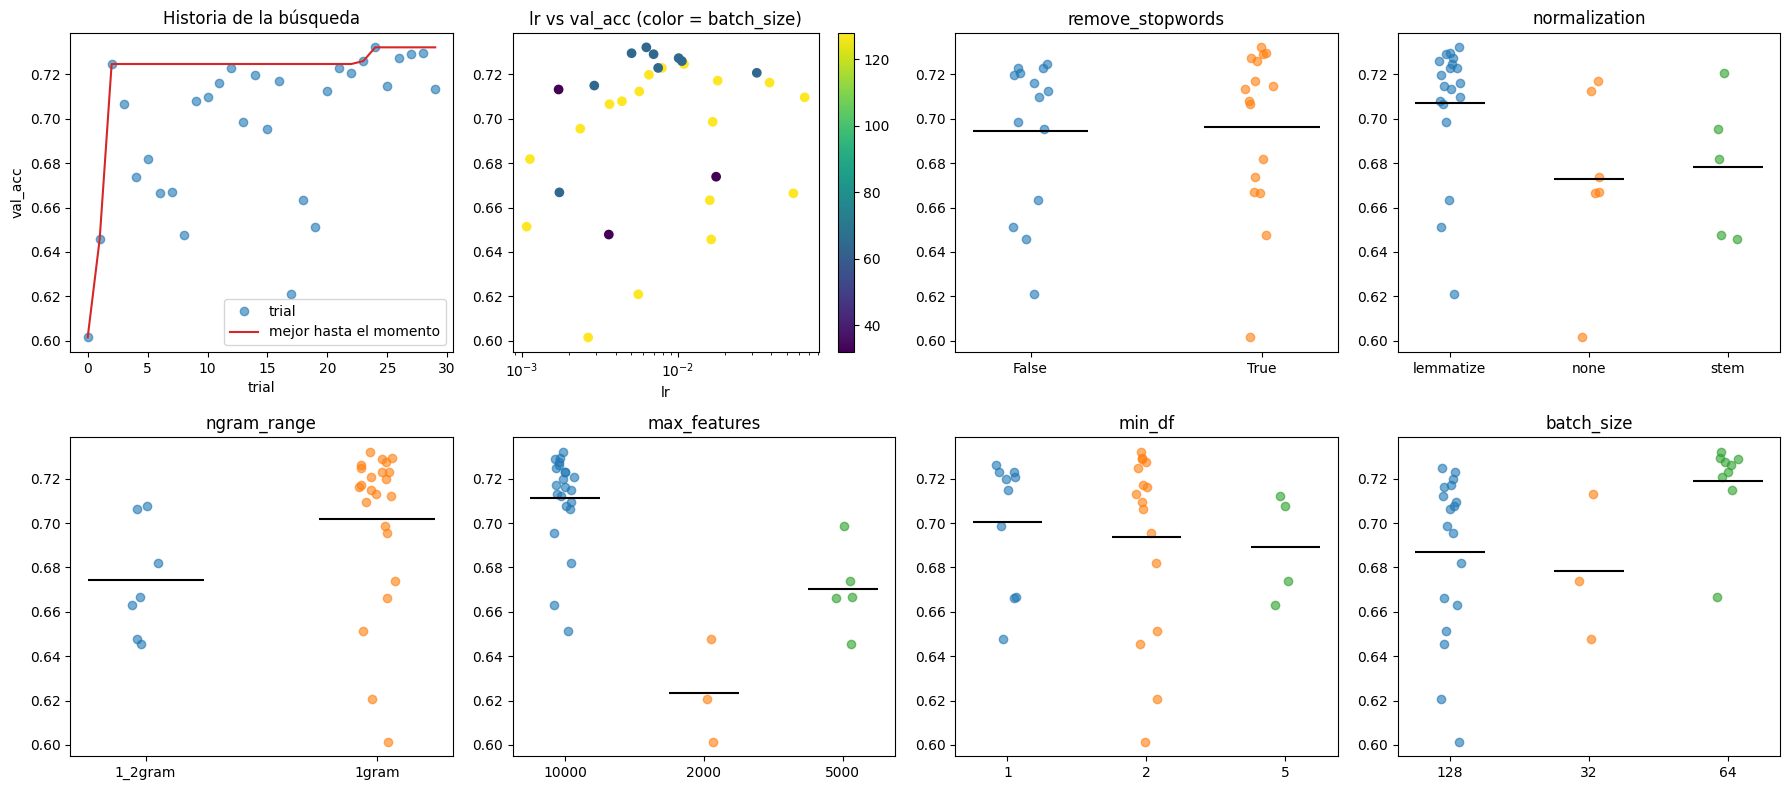

In [16]:
cat_params = ["remove_stopwords", "normalization", "ngram_range", "max_features", "min_df", "batch_size"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

# Evolución de la búsqueda
axes[0].plot(df["number"], df["val_acc"], "o", alpha=0.6, label="trial")
axes[0].plot(df["number"], df["val_acc"].cummax(), "-", color="C3", label="mejor hasta el momento")
axes[0].set(title="Historia de la búsqueda", xlabel="trial", ylabel="val_acc"); axes[0].legend()

# lr (continuo, escala log)
sc = axes[1].scatter(df["lr"], df["val_acc"], c=df["batch_size"], cmap="viridis")
axes[1].set(xscale="log", title="lr vs val_acc (color = batch_size)", xlabel="lr")
plt.colorbar(sc, ax=axes[1])

# Categóricos: cada punto es un trial, la línea es la media
for ax, p in zip(axes[2:], cat_params):
    cats = sorted(df[p].unique(), key=str)
    for i, c in enumerate(cats):
        v = df.loc[df[p] == c, "val_acc"]
        ax.scatter(np.full(len(v), i) + np.random.uniform(-0.08, 0.08, len(v)), v, alpha=0.6)
        ax.hlines(v.mean(), i - 0.25, i + 0.25, color="k")
    ax.set_xticks(range(len(cats)), [str(c) for c in cats]); ax.set_title(p)
plt.tight_layout(); plt.show()

                  count    mean     max
remove_stopwords                       
False                14  0.6946  0.7247
True                 16  0.6964  0.7322 

               count    mean     max
normalization                       
lemmatize         19  0.7072  0.7322
none               6  0.6730  0.7172
stem               5  0.6783  0.7207 

             count    mean     max
ngram_range                       
1_2gram          7  0.6743  0.7079
1gram           23  0.7020  0.7322 

              count    mean     max
max_features                       
2000              3  0.6234  0.6478
5000              5  0.6703  0.6986
10000            22  0.7112  0.7322 

        count    mean     max
min_df                       
1          10  0.7007  0.7260
2          16  0.6939  0.7322
5           4  0.6894  0.7123 

            count    mean     max
batch_size                       
32              3  0.6783  0.7132
64              9  0.7189  0.7322
128            18  0.6868  0.7247 



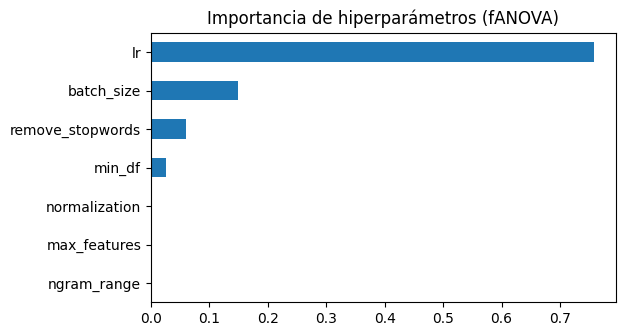

In [17]:
for p in cat_params:
    print(df.groupby(p)["val_acc"].agg(["count", "mean", "max"]).round(4), "\n")

importances = optuna.importance.get_param_importances(study)
pd.Series(importances).sort_values().plot.barh(figsize=(6, 3.5), title="Importancia de hiperparámetros (fANOVA)")
plt.show()

### Análisis de la búsqueda de hiperparámetros

**Mejor configuración** (30 trials, 5 épocas cada uno): `remove_stopwords=True`, `lemmatize`, unigramas, `max_features=10000`, `min_df=2`, `lr≈6.3e-3`, `batch_size=64` → **val_acc = 0.732**. Los 5 mejores trials comparten todo el preprocesamiento y difieren en menos de 0.6 pp: la región óptima es plana y el orden dentro del top está dentro del ruido (una sola semilla y un solo split).

**Dinámica de la búsqueda.** El trial 2 (todavía aleatorio) ya logra 0.725. A partir del trial 10, TPE se concentra en `lemmatize` / 10000 / 1gram / bs=64 (los trials 21–29 están todos por encima de 0.71) y mejora sólo +0.75 pp. Con este espacio de búsqueda, pocos trials alcanzan para ubicar la zona buena.

**Preprocesamiento** (medias por valor; ver tabla y gráficos):
- **`max_features`** es el efecto más claro: 2000 → 0.62, 5000 → 0.67, 10000 → 0.71. Con 20 clases, los términos discriminativos son muchos y específicos (nombres propios, jerga técnica). Un modelo lineal no se satura con más features, así que conviene probar más de 10000 o sin límite.
- **`ngram_range`**: unigramas (media 0.702, máx 0.732) superan a 1+2-gramas (0.674, 0.708). Con `max_features` fijo, los bigramas le quitan lugar en el vocabulario a unigramas informativos.
- **`normalization`**: `lemmatize` 0.707 vs `none` 0.673 y `stem` 0.678 en media, pero los máximos son 0.732 / 0.717 / 0.721. La muestra está desbalanceada (19/6/5 trials) porque TPE explotó `lemmatize`, y las medias de las otras opciones incluyen trials aleatorios con malos `lr`. La ganancia real ronda 1 pp: unificar formas (`drivers`→`driver`) densifica el vocabulario. El stemming agresivo mezcla palabras distintas y rinde un poco peor.
- **`remove_stopwords`**: efecto casi nulo (0.695 vs 0.696). TF-IDF ya les da peso bajo por su IDF bajo. Sacarlas sólo ayuda a liberar lugar dentro de `max_features`.
- **`min_df`**: poco efecto (1: 0.701, 2: 0.694, 5: 0.689). Con `max_features=10000`, el límite que manda es `max_features`, y `min_df` sólo recorta la cola de términos raros.

**Entrenamiento.** fANOVA atribuye ~75% de la varianza a `lr` y ~15% a `batch_size`. Los mejores trials tienen `lr` entre 5e-3 y 1.1e-2. Con `lr≈1e-3`, 5 épocas no alcanzan para converger (el trial 0 queda en 0.60), y con `lr>3e-2` el modelo sobreajusta rápido. Con bs=64 la media es 0.719, contra 0.687 con bs=128: con un número de épocas fijo, un batch más chico da el doble de actualizaciones (≈142 vs 71 por época). **La búsqueda premia a las configuraciones que convergen en 5 épocas**, porque `lr`, `batch_size` y la cantidad de épocas interactúan.

**Limitaciones.** Con 30 trials y un muestreo sesgado por TPE, las importancias de fANOVA son sólo orientativas. Por ejemplo, le asignan ~0 a `max_features` aunque su efecto en las medias es evidente: los pocos trials con 2000/5000 también tenían `lr`/`batch_size` malos, así que los efectos quedan confundidos. Para conclusiones firmes habría que repetir con varias semillas o con validación cruzada.

## 7. Entrenamiento final

Usamos los mejores hiperparámetros encontrados por Optuna, entrenamos con **todo** el train set y por más épocas, evaluando contra el test set real (que no se usó en la búsqueda).

In [18]:
best = study.best_params
BEST_REMOVE_SW = best["remove_stopwords"]
BEST_NORM = best["normalization"]
BEST_NGRAM = (1, 1) if best["ngram_range"] == "1gram" else (1, 2)
BEST_MAX_FEATURES = best["max_features"]
BEST_MIN_DF = best["min_df"]
BEST_LR = best["lr"]
BEST_BATCH_SIZE = best["batch_size"]
EPOCHS_FINAL = 20

train_texts_final, test_texts_final = preprocessed_cache[(BEST_REMOVE_SW, BEST_NORM)]
X_train_final, X_test_final, vectorizer_final = vectorize_data(
    train_texts_final, test_texts_final, BEST_NGRAM, BEST_MAX_FEATURES, BEST_MIN_DF
)

train_loader_final = DataLoader(to_tensor_dataset(X_train_final, newsgroups_train.target),
                                 batch_size=BEST_BATCH_SIZE, shuffle=True)
test_loader_final = DataLoader(to_tensor_dataset(X_test_final, newsgroups_test.target),
                                batch_size=BEST_BATCH_SIZE, shuffle=False)

model = SoftmaxRegression(input_dim=X_train_final.shape[1], num_classes=NUM_CLASSES)
optimizer = optim.Adam(model.parameters(), lr=BEST_LR)
writer = SummaryWriter(log_dir="runs/softmax_final")

mlflow.set_experiment("softmax_20newsgroups")
with mlflow.start_run(run_name="softmax_final"):
    mlflow.log_params({
        "remove_stopwords": BEST_REMOVE_SW, "normalization": BEST_NORM,
        "ngram_range": str(BEST_NGRAM), "max_features": BEST_MAX_FEATURES, "min_df": BEST_MIN_DF,
        "lr": BEST_LR, "batch_size": BEST_BATCH_SIZE, "epochs": EPOCHS_FINAL,
    })
    t0 = time.perf_counter()
    history = train_softmax_model(model, train_loader_final, test_loader_final, optimizer,
                                   epochs=EPOCHS_FINAL, writer=writer, run_name="final")
    final_train_time = time.perf_counter() - t0
    mlflow.log_metric("train_time_s", final_train_time)
    # MLflow 3.x exige un input_example para serializar el modelo
    mlflow.pytorch.log_model(model.cpu(), "model", input_example=X_test_final[:5].toarray().astype(np.float32))
    model.to(device)

writer.close()

print(f"Tiempo de entrenamiento final: {final_train_time:.1f} s ({final_train_time/EPOCHS_FINAL:.2f} s/época)")

[final] Epoch 1/20 - train_loss: 2.5076 train_acc: 0.5900 - val_loss: 2.1683 val_acc: 0.6426


[final] Epoch 2/20 - train_loss: 1.6394 train_acc: 0.8294 - val_loss: 1.7568 val_acc: 0.6649


[final] Epoch 3/20 - train_loss: 1.1852 train_acc: 0.8722 - val_loss: 1.5425 val_acc: 0.6701


[final] Epoch 4/20 - train_loss: 0.9218 train_acc: 0.8975 - val_loss: 1.4216 val_acc: 0.6706


[final] Epoch 5/20 - train_loss: 0.7523 train_acc: 0.9136 - val_loss: 1.3457 val_acc: 0.6737


...

[final] Epoch 18/20 - train_loss: 0.2100 train_acc: 0.9668 - val_loss: 1.1922 val_acc: 0.6549


[final] Epoch 19/20 - train_loss: 0.1989 train_acc: 0.9678 - val_loss: 1.1946 val_acc: 0.6541


2026/09/26 20:30:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[final] Epoch 20/20 - train_loss: 0.1890 train_acc: 0.9687 - val_loss: 1.1983 val_acc: 0.6532


Tiempo de entrenamiento final: 11.2 s (0.56 s/época)


**Explicación del código.** Se toman los mejores hiperparámetros de `study.best_params`, se reutiliza el preprocesamiento cacheado, se vectoriza con **todo** el train (11314 docs) y se entrena 20 épocas. Este run se registra en MLflow con sus parámetros, las curvas y el modelo serializado (`mlflow.pytorch.log_model`), y en TensorBoard en `runs/softmax_final`. Ojo: acá el "val" del loop es el **test**, así que estas curvas son solo para observar (no se usan para tomar decisiones).

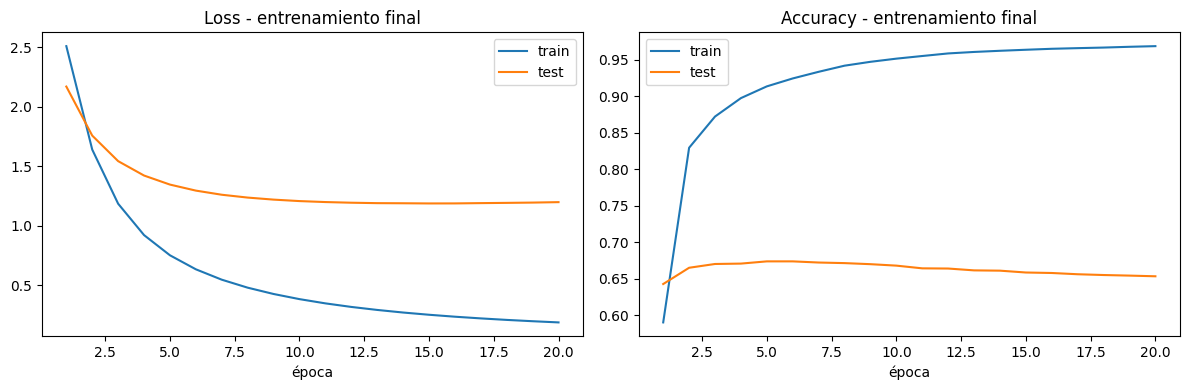

Mínimo de test loss en la época 15, máxima test acc 0.6737 en la época 5


In [19]:
ep = np.arange(1, EPOCHS_FINAL + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ep, history["train_loss"], label="train"); ax[0].plot(ep, history["val_loss"], label="test")
ax[0].set(title="Loss - entrenamiento final", xlabel="época"); ax[0].legend()
ax[1].plot(ep, history["train_acc"], label="train"); ax[1].plot(ep, history["val_acc"], label="test")
ax[1].set(title="Accuracy - entrenamiento final", xlabel="época"); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"Mínimo de test loss en la época {int(np.argmin(history['val_loss'])) + 1}, "
      f"máxima test acc {max(history['val_acc']):.4f} en la época {int(np.argmax(history['val_acc'])) + 1}")

**Análisis del entrenamiento final.**
- **Test acc = 0.653**, contra 0.732 en validación. Hay dos causas:
  1. El split *bydate* es temporal: los posts de test son posteriores y tienen otros temas e hilos, mientras que la validación sale del mismo período que el train. Eso genera *distribution shift*.
  2. Se entrenó 20 épocas con un `lr` y un `batch_size` elegidos para 5. La test acc tiene su máximo (0.674) en la **época 5** y después cae, mientras la train acc sube a 0.969: es sobreajuste. La test loss sigue bajando hasta la época 15 aunque la accuracy empeore, porque el modelo gana confianza en los aciertos al mismo tiempo que se equivoca en algunos documentos cerca de la frontera. Usar `EPOCHS_FINAL=5` o *early stopping* sobre un set de validación mejoraría el resultado.
- **Documentos vacíos**: 244 docs de test (3.2%) quedan sin ningún término del vocabulario después de sacar headers, quotes, números y stopwords. Su vector es nulo, así que los logits son sólo el bias y **todos se predicen como `rec.sport.baseball`** (la clase con mayor bias). Por eso esa clase tiene precision 0.52 y recall 0.81. Sin esos documentos, su precision sería ≈0.81. Se podrían filtrar o asignarles la clase más frecuente.

In [ ]:
%tensorboard --logdir runs


## 8. Evaluación final

In [21]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader_final:
        xb = xb.to(device)
        logits = model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())

test_accuracy = accuracy_score(all_labels, all_preds)
print(f"Accuracy en test: {test_accuracy:.4f}\n")
print(classification_report(all_labels, all_preds, target_names=class_names))


Accuracy en test: 0.6532

                          precision    recall  f1-score   support

             alt.atheism       0.48      0.45      0.47       319
           comp.graphics       0.59      0.61      0.60       389
 comp.os.ms-windows.misc       0.58      0.57      0.58       394
comp.sys.ibm.pc.hardware       0.60      0.59      0.59       392
   comp.sys.mac.hardware       0.65      0.62      0.63       385
          comp.windows.x       0.74      0.65      0.70       395
            misc.forsale       0.76      0.77      0.76       390
               rec.autos       0.68      0.66      0.67       396
         rec.motorcycles       0.70      0.69      0.70       398
      rec.sport.baseball       0.52      0.81      0.64       397
        rec.sport.hockey       0.89      0.85      0.87       399
               sci.crypt       0.79      0.70      0.75       396
         sci.electronics       0.59      0.58      0.58       393
                 sci.med       0.79      0.73    

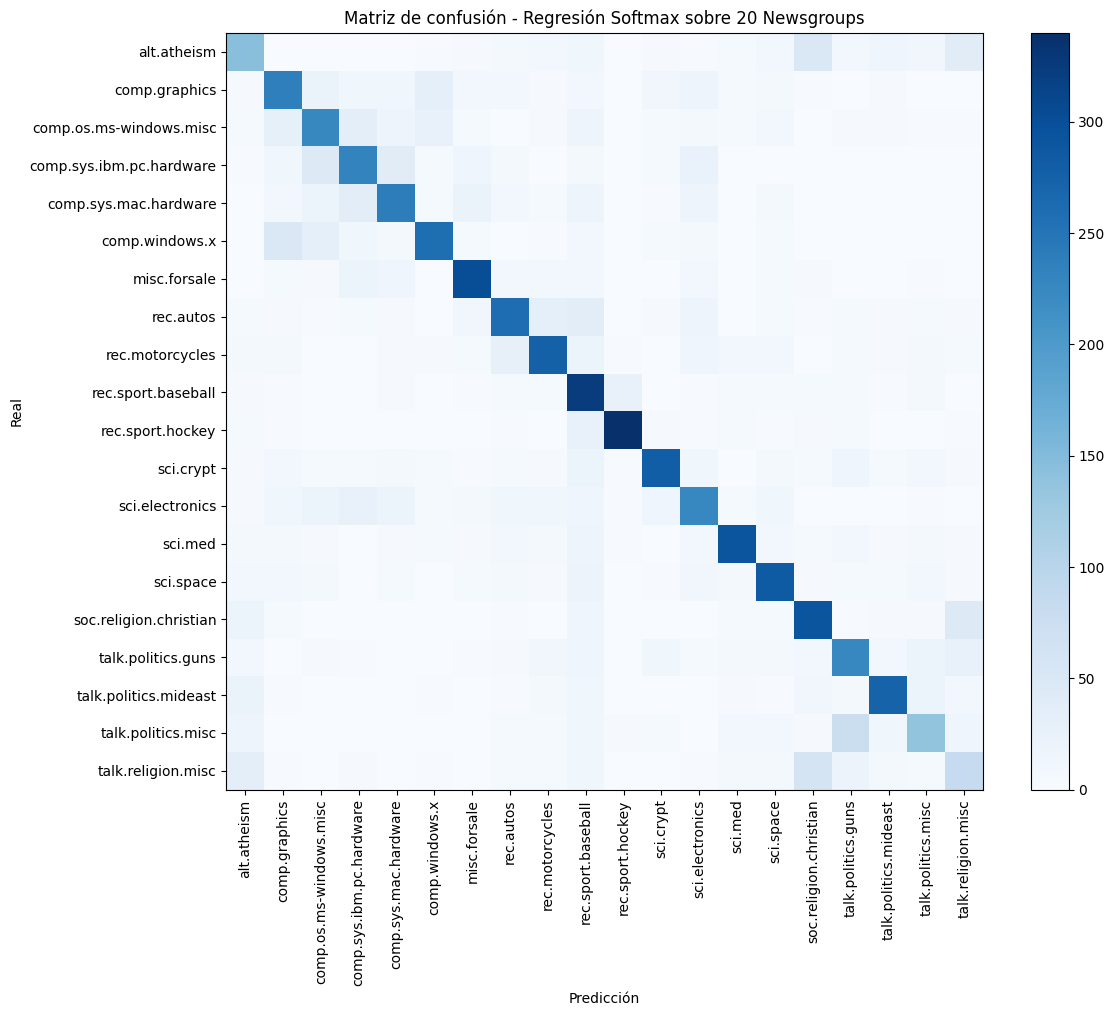

In [22]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(NUM_CLASSES), class_names, rotation=90)
plt.yticks(range(NUM_CLASSES), class_names)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Regresión Softmax sobre 20 Newsgroups")
plt.tight_layout()
plt.show()


In [23]:
# Documentos que quedan sin ningún término del vocabulario (vector TF-IDF nulo)
vacios = X_test_final.getnnz(axis=1) == 0
print(f"Documentos de test con vector nulo: {vacios.sum()} ({vacios.mean():.1%})")
print("Clase predicha para esos documentos:", pd.Series(np.array(all_preds)[vacios]).map(lambda i: class_names[i]).value_counts().to_dict())

Documentos de test con vector nulo: 244 (3.2%)
Clase predicha para esos documentos: {'rec.sport.baseball': 244}


## 8.1 Dinámica de entrenamiento en distintos casos

Fijamos el mejor preprocesamiento/vectorización y variamos **una cosa a la vez** respecto de la mejor configuración: learning rate, batch size, optimizador y regularización (`weight_decay`, penalización L2). Usamos el split train/val (no el test) y 20 épocas. Cada caso queda como run en MLflow y en TensorBoard (`runs/dyn_*`).

In [24]:
tr_texts, val_texts, tr_y, val_y = train_test_split(
    train_texts_final, newsgroups_train.target, test_size=0.2, random_state=SEED, stratify=newsgroups_train.target)
X_tr_d, X_val_d, _ = vectorize_data(tr_texts, val_texts, BEST_NGRAM, BEST_MAX_FEATURES, BEST_MIN_DF)
ds_tr, ds_val = to_tensor_dataset(X_tr_d, tr_y), to_tensor_dataset(X_val_d, val_y)
EPOCHS_DYN = 20


def run_experiment(name, opt_name="adam", lr=BEST_LR, batch_size=BEST_BATCH_SIZE, weight_decay=0.0, epochs=EPOCHS_DYN):
    torch.manual_seed(SEED)
    model = SoftmaxRegression(ds_tr.tensors[0].shape[1], NUM_CLASSES)
    opt_cls = {"adam": optim.Adam, "sgd": optim.SGD}[opt_name]
    optimizer = opt_cls(model.parameters(), lr=lr, weight_decay=weight_decay)
    tr_loader = DataLoader(ds_tr, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(ds_val, batch_size=512)
    writer = SummaryWriter(log_dir=f"runs/dyn_{name}")
    with mlflow.start_run(run_name=f"dyn_{name}"):
        mlflow.log_params(dict(optimizer=opt_name, lr=lr, batch_size=batch_size, weight_decay=weight_decay, epochs=epochs))
        t0 = time.perf_counter()
        with contextlib.redirect_stdout(io.StringIO()):   # no imprimir 20 líneas por run
            h = train_softmax_model(model, tr_loader, val_loader, optimizer, epochs, writer=writer, run_name=name)
        h["time_s"] = time.perf_counter() - t0
        mlflow.log_metric("train_time_s", h["time_s"])
    writer.close()
    return h


grupos = {
    "Learning rate (Adam)": {
        "lr=1e-3": dict(lr=1e-3), "lr=1e-2": dict(lr=1e-2), "lr=1e-1": dict(lr=1e-1)},
    "Batch size (Adam, mejor lr)": {
        "bs=16": dict(batch_size=16), "bs=128": dict(batch_size=128), "bs=512": dict(batch_size=512)},
    "Optimizador / regularización": {
        "Adam (mejor)": dict(), "SGD lr=1": dict(opt_name="sgd", lr=1.0),
        "SGD lr=10": dict(opt_name="sgd", lr=10.0), "Adam + wd=1e-4": dict(weight_decay=1e-4)},
}

results = {}
for g, casos in grupos.items():
    for name, kw in casos.items():
        results[name] = run_experiment(name.replace(" ", "_").replace("=", ""), **kw)
        print(f"{name:16s} listo - val_acc final {results[name]['val_acc'][-1]:.4f} - {results[name]['time_s']:.1f} s")

lr=1e-3          listo - val_acc final 0.7234 - 7.6 s


lr=1e-2          listo - val_acc final 0.7101 - 7.6 s


lr=1e-1          listo - val_acc final 0.6898 - 8.1 s


bs=16            listo - val_acc final 0.7039 - 16.4 s


bs=128           listo - val_acc final 0.7243 - 5.8 s


bs=512           listo - val_acc final 0.7212 - 6.4 s


Adam (mejor)     listo - val_acc final 0.7194 - 8.0 s


SGD lr=1         listo - val_acc final 0.6947 - 7.2 s


SGD lr=10        listo - val_acc final 0.7212 - 6.7 s


Adam + wd=1e-4   listo - val_acc final 0.7207 - 8.4 s


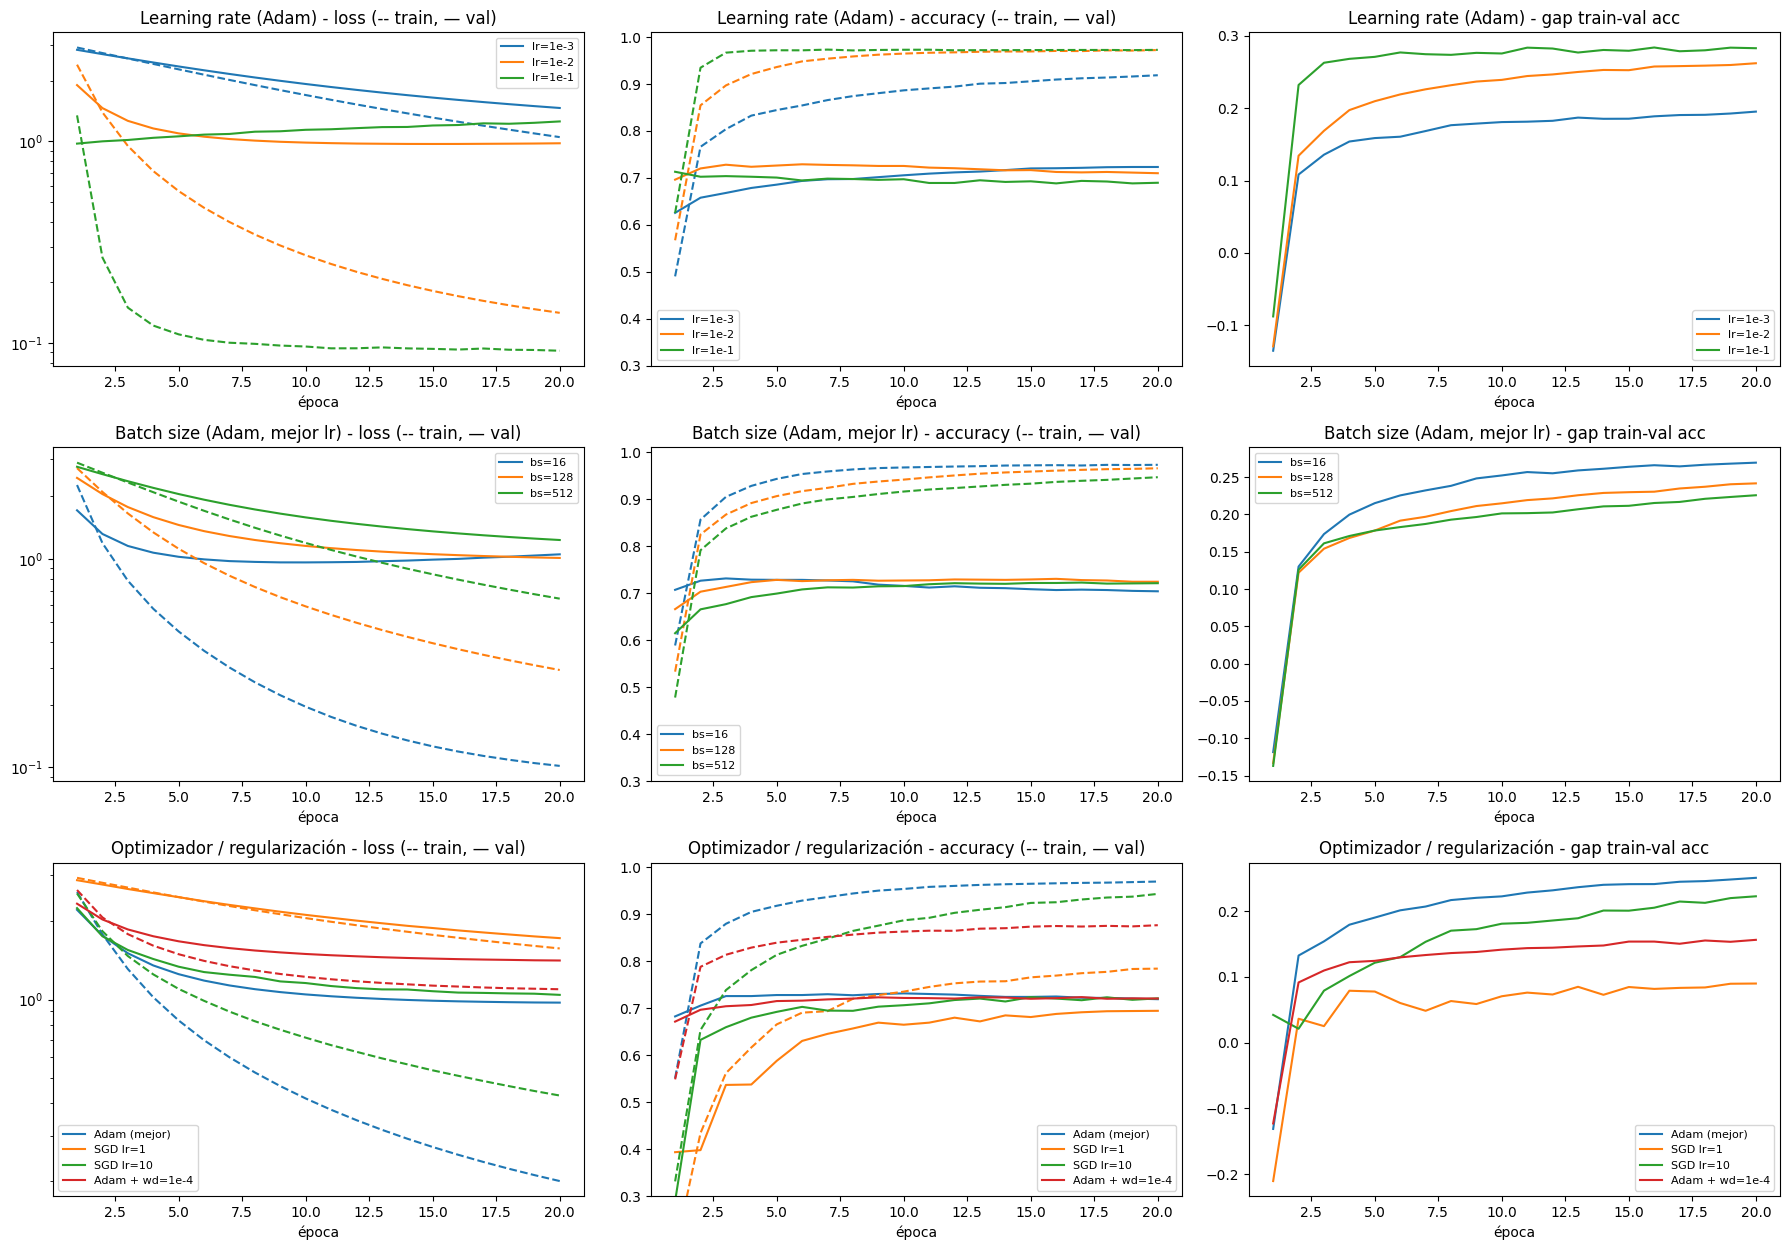

In [25]:
ep = np.arange(1, EPOCHS_DYN + 1)
fig, axes = plt.subplots(len(grupos), 3, figsize=(18, 4.2 * len(grupos)))
for row, (g, casos) in zip(axes, grupos.items()):
    for i, name in enumerate(casos):
        h = results[name]
        row[0].plot(ep, h["train_loss"], "--", color=f"C{i}"); row[0].plot(ep, h["val_loss"], color=f"C{i}", label=name)
        row[1].plot(ep, h["train_acc"], "--", color=f"C{i}"); row[1].plot(ep, h["val_acc"], color=f"C{i}", label=name)
        row[2].plot(ep, np.array(h["train_acc"]) - np.array(h["val_acc"]), color=f"C{i}", label=name)
    row[0].set(title=f"{g} - loss (-- train, — val)", xlabel="época", yscale="log")
    row[1].set(title=f"{g} - accuracy (-- train, — val)", xlabel="época", ylim=(0.3, 1.01))
    row[2].set(title=f"{g} - gap train-val acc", xlabel="época")
    for a in row: a.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Análisis de la dinámica de entrenamiento

**Patrón general.** En casi todos los casos la train acc llega a 0.92–0.97 mientras la val acc se estanca en ~0.72 desde la época 2–5, con un gap de 20–28 pp. El modelo tiene ~200k parámetros para ~9000 documentos, y en 10000 dimensiones TF-IDF el train es casi linealmente separable: el modelo lo puede casi memorizar. El techo de ~0.73 en validación viene de la representación (*bag of words*) y de la superposición temática entre clases, no del optimizador.

**Learning rate (Adam, bs=64):**
- `1e-3`: convergencia lenta y monótona. La val acc sube hasta 0.723 en la época 19 y la val loss todavía baja en la época 20, así que no terminó de converger. Es el caso con menos sobreajuste (train 0.92).
- `1e-2`: pico de 0.729 en la época 6 y después baja a 0.710. La val loss tiene su mínimo en la época 15.
- `1e-1`: el máximo (0.713) ya está en la época 1. La train loss baja a ~0.09 pero la **val loss sube desde la primera época**. Los pesos crecen rápido y el modelo se vuelve sobreconfiado: la val loss aumenta aunque la val acc quede ~constante (0.69).

**Batch size (Adam, lr≈6.3e-3):**
- `16`: ~566 actualizaciones por época. Converge en 2 épocas (pico 0.731 en la 3), pero después sobreajusta: la val loss sube desde la época 10 y termina en 0.704.
- `128` / `512`: curvas más suaves y lentas (71 y 18 actualizaciones por época). Con 512 el pico (0.723) llega recién en la época 17, pero es el caso con menor gap (train 0.947).
- El efecto es parecido a cambiar el `lr`: lo que importa es cuánto se mueven los pesos por época (≈ nº de actualizaciones × lr). Además, un batch chico agrega ruido al gradiente.

**Optimizador y regularización:**
- **SGD `lr=1`** es mucho más lento: después de 20 épocas tiene train 0.78 y val 0.695, todavía subiendo. Los vectores TF-IDF tienen norma L2 = 1, así que cada feature toma valores muy chicos y sus gradientes también lo son. SGD necesita un `lr` enorme (`lr=10` llega a 0.724 en la época 15). Adam normaliza el paso de cada peso con el segundo momento de su gradiente, así que cada peso avanza ~`lr` sin importar la escala. Eso es clave con features dispersas y términos raros, y por eso converge en 2–3 épocas.
- **`weight_decay=1e-4`** (penalización L2): la train acc baja de 0.970 a 0.877 y el gap pasa de 25 a 16 pp. La val acc ya no cae con las épocas (0.721 final vs 0.719 sin regularización). Sin embargo, el máximo no mejora (0.724 vs 0.732). La regularización controla el sobreajuste, pero no sube el techo que impone la representación.

## 8.2 Tiempos de convergencia

Definimos la **época de convergencia** como la primera época en que la accuracy de validación llega a 1 punto porcentual de su máximo. Reportamos también la época de mínima val loss (a partir de la cual el modelo empieza a sobreajustar) y el tiempo en segundos (tiempo total / épocas × época de convergencia). Los segundos dependen del hardware (CPU/GPU); las épocas no.

In [26]:
def convergencia(h, tol=0.01):
    va, vl = np.array(h["val_acc"]), np.array(h["val_loss"])
    ep_conv = int(np.argmax(va >= va.max() - tol)) + 1
    t_ep = h["time_s"] / len(va)
    return {"max_val_acc": va.max(), "ép. max acc": int(va.argmax()) + 1, "ép. min val_loss": int(vl.argmin()) + 1,
            "ép. convergencia": ep_conv, "s/época": t_ep, "t. convergencia [s]": ep_conv * t_ep,
            "val_acc final": va[-1], "train_acc final": h["train_acc"][-1]}

conv = pd.DataFrame({k: convergencia(h) for k, h in results.items()}).T
conv.style.format({c: "{:.4f}" for c in ["max_val_acc", "val_acc final", "train_acc final"]} | {"s/época": "{:.2f}", "t. convergencia [s]": "{:.1f}"})

,max_val_acc,ép. max acc,ép. min val_loss,ép. convergencia,s/época,t. convergencia [s],val_acc final,train_acc final
lr=1e-3,0.7234,19.000000,20.000000,13.000000,0.38,4.9,0.7234,0.9187
lr=1e-2,0.7291,6.000000,15.000000,2.000000,0.38,0.8,0.7101,0.9723
lr=1e-1,0.7132,1.000000,1.000000,1.000000,0.40,0.4,0.6898,0.9727
bs=16,0.7313,3.000000,10.000000,2.000000,0.82,1.6,0.7039,0.9732
bs=128,0.7304,16.000000,20.000000,4.000000,0.29,1.2,0.7243,0.9657
bs=512,0.7225,17.000000,20.000000,9.000000,0.32,2.9,0.7212,0.9467
Adam (mejor),0.7318,10.000000,20.000000,3.000000,0.40,1.2,0.7194,0.9698
SGD lr=1,0.6947,20.000000,20.000000,14.000000,0.36,5.1,0.6947,0.7844
SGD lr=10,0.7238,15.000000,20.000000,12.000000,0.33,4.0,0.7212,0.9435
Adam + wd=1e-4,0.7238,17.000000,20.000000,5.000000,0.42,2.1,0.7207,0.8769


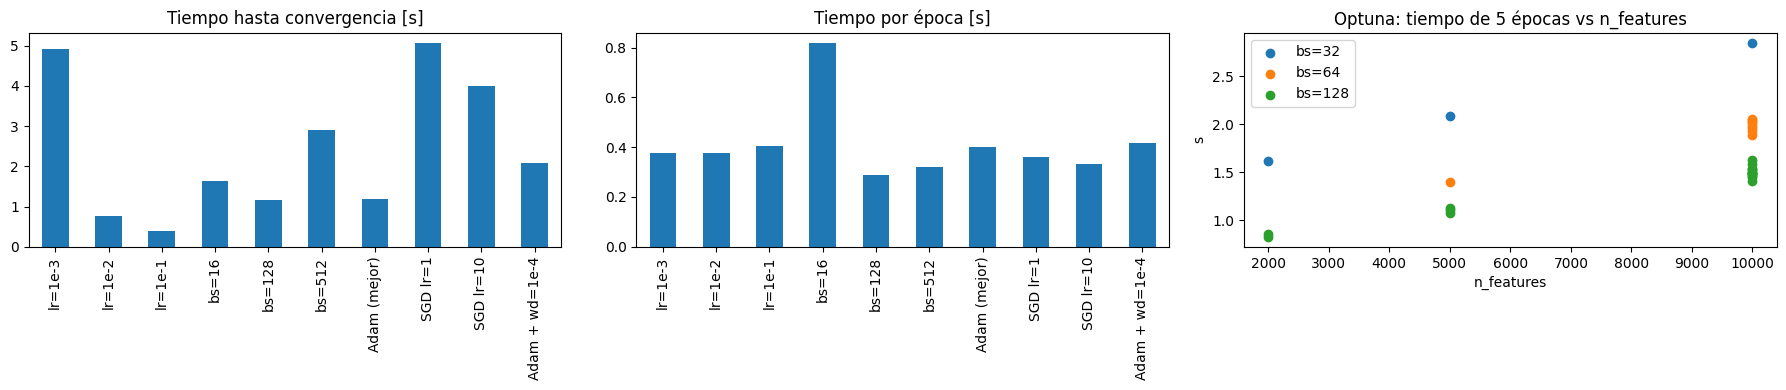

In [27]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
conv["t. convergencia [s]"].plot.bar(ax=ax[0], title="Tiempo hasta convergencia [s]")
conv["s/época"].plot.bar(ax=ax[1], title="Tiempo por época [s]")

# En la búsqueda de Optuna: costo de 5 épocas según batch size y tamaño de entrada
for bs, grp in df.groupby("batch_size"):
    ax[2].scatter(grp["n_features"], grp["train_time_s"], label=f"bs={bs}")
ax[2].set(title="Optuna: tiempo de 5 épocas vs n_features", xlabel="n_features", ylabel="s"); ax[2].legend()
plt.tight_layout(); plt.show()

### Análisis de tiempos de convergencia

*(Tiempos medidos en CPU. En GPU o Colab cambian los segundos, pero no las épocas.)*

- **Épocas hasta converger** (llegar a 1 pp del máximo de val acc): `lr=1e-1` → 1, `lr=1e-2` y `bs=16` → 2, Adam con la mejor config → 3, `bs=128` → 4, `wd=1e-4` → 5, `bs=512` → 9, SGD `lr=10` → 12, `lr=1e-3` → 13, SGD `lr=1` → 14 (y sigue subiendo, así que no convergió en realidad).
- **Costo por época**: ~0.3–0.4 s, casi independiente del `lr`, del optimizador y de la regularización. El costo lo dominan el producto matricial (batch × 10000 × 20) y el overhead del loop de Python y del DataLoader. Lo que sí influye es el **batch size**: con `bs=16` una época tarda 0.82 s (≈2× más) por hacer 566 iteraciones, y con 128/512 tarda ~0.3 s. En la búsqueda de Optuna se ve lo mismo: el tiempo de 5 épocas crece con `n_features` y baja con el batch (a 10000 features, 2.8 s con bs=32 vs 1.5 s con bs=128).
- **Tiempo hasta converger** (épocas × s/época): los más rápidos son `lr=1e-2` (0.8 s), Adam con la mejor config y `bs=128` (~1.2 s). `bs=16` converge en menos épocas, pero cada una cuesta el doble (1.6 s). Los más lentos son `lr=1e-3` (4.9 s) y SGD (4–5 s). `lr=1e-1` es el más rápido (0.4 s), pero converge a una solución peor.
- **Conclusión**: con Adam y `lr` entre 5e-3 y 1e-2, la regresión softmax converge en **2–5 épocas**. Seguir entrenando sólo aumenta el sobreajuste. El entrenamiento final de 20 épocas gasta ~75% del cómputo en empeorar la test acc (máximo en la época 5). *Early stopping* sobre la val loss o la val acc con paciencia ~3 ahorraría ese tiempo y daría un mejor modelo.

## 9. Preguntas de reflexión

**Sobre Regresión Softmax (teoría)**
1. ¿Por qué la regresión softmax es una generalización de la regresión logística binaria? ¿Qué pasaría si `NUM_CLASSES = 2`?
2. ¿Por qué `CrossEntropyLoss` en PyTorch no necesita que se le aplique `softmax` antes en el forward? ¿Qué pasaría si igual lo aplicaran (softmax + CrossEntropyLoss)?
3. ¿Qué tipo de frontera de decisión puede aprender un modelo de regresión softmax? ¿Qué limitación tiene frente a un problema que no es linealmente separable?
4. ¿En qué se diferencia este modelo de una red neuronal con capas ocultas? ¿En qué situación elegirían una sobre la otra?

**Sobre frameworks y herramientas**
5. ¿Qué ventajas y desventajas tiene implementar esto en PyTorch (como hicimos) comparado con usar directamente `sklearn.linear_model.LogisticRegression(multi_class="multinomial")`?
6. ¿Para qué sirvió específicamente MLflow en este TP? ¿En qué se diferencia de lo que loguea TensorBoard?
7. ¿Qué ventaja concreta les dio Optuna frente a probar combinaciones de hiperparámetros a mano?

**Sobre el experimento**
8. ¿Qué combinación de preprocesamiento (stopwords, stemming/lematización, n-gramas) encontró Optuna como mejor? ¿Tiene sentido para este dataset?
9. ¿En qué categorías del dataset se confunde más el modelo (según la matriz de confusión)? ¿Por qué creen que pasa (piensen en el contenido temático de esas categorías)?
10. ¿Cambiaría su respuesta a la pregunta anterior si usaran un modelo con capas ocultas en vez de regresión softmax? ¿Por qué sí o por qué no?


## Respuestas

**1. Softmax como generalización de la logística binaria.**
Con K=2, softmax da p(y=1|x) = e^{z₁}/(e^{z₀}+e^{z₁}) = σ(z₁ − z₀), que es exactamente una regresión logística con pesos w = w₁ − w₀ y sesgo b = b₁ − b₀. Con `NUM_CLASSES = 2` el modelo funciona igual, pero está sobreparametrizado: sumarle el mismo vector a ambos w_k no cambia las probabilidades, así que hay infinitas soluciones equivalentes. Por eso, en el caso binario, se usa una sola salida con `BCEWithLogitsLoss`. Lo mismo pasa con K clases: el softmax es invariante a sumar una constante a todos los logits, así que en realidad sólo hay K−1 vectores de pesos "libres".

**2. Por qué no aplicar softmax en el forward.**
`CrossEntropyLoss` aplica internamente `log_softmax` + `NLLLoss`, calculado con el truco log-sum-exp para evitar overflow y la pérdida de precisión de `log(softmax(z))` cuando alguna probabilidad es muy chica. Si el modelo ya devuelve un softmax, se aplica dos veces: la loss toma probabilidades en [0,1] como si fueran logits. Como los "logits" quedan entre 0 y 1, el segundo softmax da distribuciones casi uniformes. Aun con una salida perfecta (one-hot), la probabilidad máxima es e/(e+19) ≈ 0.125, así que la loss nunca baja de ≈2.08. Además, el gradiente queda multiplicado por el jacobiano del primer softmax, que es muy chico cuando las salidas están saturadas, y el entrenamiento se vuelve muy lento o se estanca. El `argmax` no cambia, pero el modelo aprende mucho peor.

**3. Frontera de decisión.**
La clase k gana donde w_k·x + b_k ≥ w_j·x + b_j para todo j, así que:
- la frontera entre cada par de clases es un hiperplano, (w_k − w_j)·x + (b_k − b_j) = 0;
- la región de cada clase es la intersección de semiespacios, un poliedro convexo.

El modelo no puede separar clases que no son linealmente separables (XOR, clases no convexas o distribuidas en varias zonas) sin transformar las features a mano (bigramas, kernels). Sin embargo, en este problema la linealidad no es el cuello de botella. Con 10000 dimensiones y ~9000 documentos, el train es casi linealmente separable (train acc ≈ 0.97). En alta dimensión casi cualquier conjunto es separable (teorema de Cover). El límite de ~0.74 en validación viene de la representación (*bag of words*, sin orden ni contexto), no de la forma de la frontera.

**4. Diferencias con una red con capas ocultas.**
Una red con capas ocultas y activaciones no lineales aprende representaciones intermedias y puede aproximar fronteras arbitrarias, pero la loss deja de ser convexa: depende de la inicialización, tiene más hiperparámetros (arquitectura, dropout, etc.) y sobreajusta más fácil. La regresión softmax es convexa (tiene un único óptimo global), entrena en pocas épocas (acá converge en 2–3), es barata y es interpretable: cada peso w_{k,i} dice cuánto aporta la palabra i a la clase k.

Elegiría softmax cuando:
- las features ya son informativas, ralas y de alta dimensión (TF-IDF),
- hay pocos datos,
- se necesita un baseline o interpretabilidad.

Elegiría una red cuando:
- las features son densas o de bajo nivel (embeddings, píxeles, señales),
- hay muchos datos,
- importan las interacciones no lineales entre features.

**5. PyTorch vs `sklearn.linear_model.LogisticRegression`.**

Ventajas de sklearn:
- Se resuelve en pocas líneas.
- Trabaja con la matriz rala directamente, sin densificar (acá densificar ocupa ~450 MB).
- Sus solvers (lbfgs, saga) llegan al óptimo exacto del problema convexo, con regularización L2 incluida (`C`).
- No hay que elegir lr, batch size ni épocas, así que no aparece el sobreajuste por entrenar de más que vimos en el entrenamiento final.
- Es determinístico.

Ventajas de PyTorch:
- Control total del loop: se ven las métricas por época, lo que permitió analizar la dinámica y la convergencia.
- Se pueden usar distintos optimizadores (Adam, SGD) y regularizaciones.
- Se integra con TensorBoard y MLflow.
- Usa GPU (aunque acá no ayudó por el tamaño del modelo).
- Pasar a una red con capas ocultas es cambiar dos líneas.

La contracara de PyTorch es más código y más hiperparámetros para ajustar. Además, el resultado depende del optimizador y de cuándo se corta el entrenamiento.

**6. MLflow vs TensorBoard.**
MLflow funcionó como un sistema de *experiment tracking*. Cada trial de Optuna, el entrenamiento final y cada experimento de dinámica quedaron como runs independientes, con sus hiperparámetros, las métricas por época, el tiempo de entrenamiento y (en el run final) el modelo serializado y recargable con `mlflow.pytorch.load_model`. Todo queda persistido en una base y se puede consultar, filtrar y comparar en una tabla, lo que sirve para reproducir resultados y seguir la trazabilidad del modelo.

TensorBoard es una herramienta de visualización. Muestra las curvas escalares por época de cada run (con los runs superpuestos, útil para comparar la dinámica entre casos), en vivo durante el entrenamiento. No organiza los runs por hiperparámetros (salvo con el plugin HParams) ni guarda modelos o artefactos. En la práctica son complementarios: TensorBoard para ver cómo entrena, MLflow para registrar qué se entrenó y con qué configuración.

**7. Qué aportó Optuna.**
El espacio de búsqueda tenía 7 hiperparámetros, mezclando categóricos y un continuo en escala log. Una grilla con sólo 5 valores de lr serían 1620 combinaciones, cada una con vectorización + entrenamiento. Optuna encontró una buena configuración en 30 trials:
- **Menos corridas:** los primeros 10 trials son aleatorios, y después TPE modela qué zonas del espacio dan buenos resultados y concentra ahí los intentos. La mejor val acc mejoró +1.7 pp respecto de la mejor configuración aleatoria.
- **Un solo `objective`:** optimiza preprocesamiento y entrenamiento en conjunto, con lo que captura sus interacciones (por ejemplo, el mejor lr depende del batch size).
- **Herramientas de análisis:** `trials_dataframe` e importancias de hiperparámetros (usadas en el análisis), reproducibilidad con semilla y *pruning* para cortar trials malos antes de terminar.

La limitación es que el resultado depende del camino que toma la búsqueda. La corrida en CPU y la de GPU terminaron en configuraciones distintas (lemmatize/bs=64 vs stem/bs=32) con desempeño equivalente. Por eso las diferencias chicas entre las mejores configuraciones no son significativas.

**8. Mejor preprocesamiento encontrado.**
Optuna eligió stopwords removidas, stemming, unigramas, `max_features=10000` y `min_df=1`, con val acc de 0.743. Tiene sentido para clasificar por tema, porque el tema lo definen palabras clave de contenido (*hockey*, *encryption*, *orbit*) y el orden de las palabras importa poco:
- **Tamaño del vocabulario:** es el factor más consistente. La media pasa de 0.63 con 2000 features a 0.72 con 10000. Los términos más discriminativos suelen ser específicos (nombres propios, jerga técnica), y un límite chico los deja afuera.
- **Unigramas:** superan a 1+2-gramas porque, con `max_features` fijo, los bigramas le quitan lugar a unigramas informativos. Además, con ~11k documentos la mayoría de los bigramas aparece muy pocas veces.
- **Normalización:** mejora claramente frente a no normalizar (media 0.65 sin normalizar), porque junta variantes de la misma palabra y reduce la dispersión. Stem vs lemmatize no es una diferencia robusta: en la corrida en CPU ganó lemmatize.
- **Stopwords:** sacarlas aporta poco, porque TF-IDF ya les da poco peso por su IDF bajo. Su principal beneficio es liberar lugar dentro de `max_features`.

**9. Categorías donde más se confunde el modelo.**
Según la matriz de confusión y el `classification_report`, las principales confusiones son:
- `talk.politics.misc` → `talk.politics.guns` (f1 de politics.misc: 0.47)
- `talk.religion.misc` → `soc.religion.christian` y `alt.atheism` (f1 de religion.misc: 0.32, la peor clase)
- `alt.atheism` ↔ `soc.religion.christian`
- las `comp.*` entre sí: `ibm.pc.hardware` ↔ `mac.hardware` y `graphics` / `windows.x` ↔ `ms-windows.misc`
- `sci.electronics` con las de hardware
- `rec.autos` ↔ `rec.motorcycles`

Las causas son:
- **Vocabulario compartido:** las tres categorías de religión debaten sobre lo mismo (*god, jesus, bible, belief*); PC y Mac comparten términos de hardware (*drive, scsi, card, monitor*); autos y motos comparten *engine, oil, tires*.
- **Categorías `.misc`:** son cajones de sastre que se superponen temáticamente con sus grupos hermanos. Un post sobre control de armas puede estar legítimamente en `politics.misc` o en `politics.guns`.

Además hay un artefacto del preprocesamiento: 243 documentos de test quedan vacíos (vector nulo) y se predicen todos como `rec.autos`, la clase con mayor bias. Por eso `rec.autos` tiene precision 0.46 a pesar de ser una clase fácil.

**10. ¿Cambiaría con un modelo con capas ocultas?**
Probablemente poco. La regresión softmax ya casi memoriza el train (0.97) y se queda en ~0.74 de validación, así que el problema no es la capacidad sino la generalización. Un modelo con más parámetros sobre las mismas features TF-IDF tendería a sobreajustar más. Las confusiones de la pregunta anterior vienen de que la representación *bag of words* no tiene la información para distinguir esas clases: dos posts con el mismo vocabulario tienen vectores parecidos y ninguna frontera, lineal o no, los separa bien. Algunos casos son ambiguos incluso para una persona, por la superposición entre categorías.

Lo que sí podría ayudar es cambiar la representación:
- embeddings de palabras,
- modelos contextuales tipo transformer, que capten el contexto, la postura y el orden.

Los documentos vacíos no los resuelve ningún modelo: hay que tratarlos en el preprocesamiento.